# Data Exploration and Processing
## Sugar Alternative Whitespace Analysis

**Dataset:** USDA FoodData Central - US Branded Foods (50K sample)

**Objective:** Identify market opportunities for sugar alternative products

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Setting plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Part 1: Data Loading


In [ ]:
from google.colab import files

# Uploading data file
print("Upload us_products_sample_50k.csv:")
uploaded = files.upload()

Upload us_products_sample_50k.csv:


Saving us_products_sample_50k.csv to us_products_sample_50k.csv


In [ ]:
# Loading data
df = pd.read_csv('us_products_sample_50k.csv', low_memory=False)

print(f"Loaded {len(df):,} US food products")
print(f"Dataset shape: {df.shape}")

Loaded 49,862 US food products
Dataset shape: (49862, 25)


## Part 2: Initial Data Exploration


In [ ]:
# Displaying column names
print("Column names:")
print(df.columns.tolist())
# Checking data types
print("Data types:")
print(df.dtypes)

Column names:
['fdc_id', 'brand_owner', 'brand_name', 'subbrand_name', 'gtin_upc', 'ingredients', 'not_a_significant_source_of', 'serving_size', 'serving_size_unit', 'household_serving_fulltext', 'branded_food_category', 'data_source', 'package_weight', 'modified_date', 'available_date', 'market_country', 'discontinued_date', 'preparation_state_code', 'trade_channel', 'short_description', 'material_code', 'description', 'fat_100g', 'protein_100g', 'sugar_100g']
Data types:
fdc_id                           int64
brand_owner                     object
brand_name                      object
subbrand_name                   object
gtin_upc                        object
ingredients                     object
not_a_significant_source_of     object
serving_size                   float64
serving_size_unit               object
household_serving_fulltext      object
branded_food_category           object
data_source                     object
package_weight                  object
modified_date  

In [ ]:
# Selecting only needed columns
columns_needed = [
    'fdc_id',
    'description',
    'branded_food_category',
    'ingredients',
    'sugar_100g'
]
df = df[columns_needed]
print(f"Selected columns: {', '.join(columns_needed)}")

# Checking completeness
print("Data completeness:")
df.isnull().sum()

Selected columns: fdc_id, description, branded_food_category, ingredients, sugar_100g
Data completeness:


,0
fdc_id,0
description,0
branded_food_category,0
ingredients,0
sugar_100g,0


In [ ]:
# Displaying first few rows
print("First 10 products:")
df.head(10)

First 10 products:


,fdc_id,description,branded_food_category,ingredients,sugar_100g
0,1093681,"LEMON SOUR MIX, LEMON",Alcohol,"FILTERED WATER, CANE SUGAR, LEMON JUICE FROM C...",17.80
1,1939570,PINA COLADA & CHI-CHI MIX,Alcohol,"TRIPLE-FILTERED WATER, SUGAR, PROPYLENE GLYCOL...",29.17
2,1962904,"STRAWBERRY MIX COCKTAILS, STRAWBERRY",Alcohol,"HIGH FRUCTOSE CORN SYRUP, WATER, STRAWBERRY PU...",35.83
3,1363197,CUCUMBER DILL BLOODY MARY MIXER,Alcohol,"WATER, TOMATO PASTE, CUCUMBER, CUCUMBER JUICE,...",6.67
4,571127,LIGHT MARGARITA MIX,Alcohol,"WATER, CITRIC ACID, NATURAL FLAVORS, CONTAINS ...",0.00
5,2530956,HANDCRAFTED WATERMELON DAIQUIRI & MARGARITA CO...,Alcohol,"WATER, SUGAR, WATERMELON JUICE FROM CONCENTRAT...",35.83
6,1939352,"NON-ALCOHOLIC COCKTAIL MIX, MOJITO",Alcohol,"CANE SUGAR, WATER, CITRIC ACID, CARBON DIOXIDE...",51.92
7,1939449,"BLOODY MARY MIX, SPICY",Alcohol,"WATER, TOMATO PASTE, DISTILLED VINEGAR, WORCES...",4.17
8,558988,TONIC WATER,Alcohol,"CARBONATED WATER, CITRIC ACID, NATURAL FLAVORS...",0.00
9,2596447,"LEMONADE DRINK MIX, LEMONADE",Alcohol,"CITRIC ACID, NATURAL LEMON FLAVOR WITH OTHER N...",0.00


## Part 3: Sugar Content Analysis


Sugar content statistics (per 100g):
count    49862.000000
mean        15.852618
std         21.055108
min          0.000000
25%          1.410000
50%          5.710000
75%         23.600000
max        100.000000
Name: sugar_100g, dtype: float64

Sugar distribution by bins:
sugar_bin
0-5g       14601
5-25g      13965
25-50g      7335
50-75g      3313
75-100g     1089
Name: count, dtype: int64


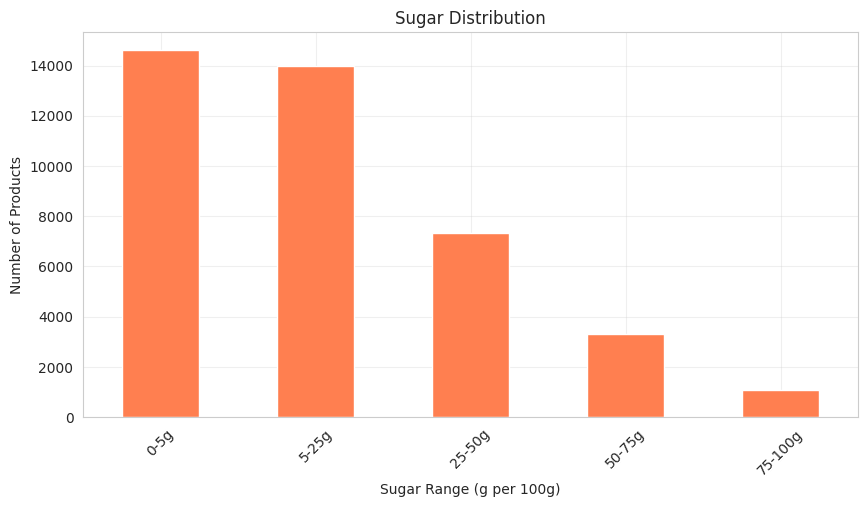

In [ ]:
# Sugar content statistics
print("Sugar content statistics (per 100g):")
print(df['sugar_100g'].describe())

# Creating sugar bins
bins = [0, 5, 25, 50, 75, 100]
labels = ['0-5g', '5-25g', '25-50g', '50-75g', '75-100g']
df['sugar_bin'] = pd.cut(df['sugar_100g'], bins=bins, labels=labels)

print("\nSugar distribution by bins:")
print(df['sugar_bin'].value_counts().sort_index())

# Simple bar chart
df['sugar_bin'].value_counts().sort_index().plot(kind='bar', color='coral', figsize=(10, 5))
plt.xlabel('Sugar Range (g per 100g)')
plt.ylabel('Number of Products')
plt.title('Sugar Distribution')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## Part 4: Category Analysis


In [ ]:
# Category overview
print("Category overview:")
print(f"Total unique categories: {df['branded_food_category'].nunique()}")

print("Top 20 categories by product count:")
display(df['branded_food_category'].value_counts().head(20))

Category overview:
Total unique categories: 219
Top 20 categories by product count:


,count
branded_food_category,
"Popcorn, Peanuts, Seeds & Related Snacks",2439
Candy,2378
Cheese,2110
Ice Cream & Frozen Yogurt,1615
Cookies & Biscuits,1433
"Chips, Pretzels & Snacks",1349
Breads & Buns,1246
Chocolate,1114
"Fruit & Vegetable Juice, Nectars & Fruit Drinks",1085


In [ ]:
# Categories with highest average sugar
print("Categories with highest average sugar content:")

# Calculating average sugar per category (minimum 20 products)
cat_sugar = df.groupby('branded_food_category')['sugar_100g'].agg(['mean', 'count'])
cat_sugar = cat_sugar[cat_sugar['count'] >= 20]
cat_sugar = cat_sugar.sort_values('mean', ascending=False)

print("\nTop 15 highest sugar categories:")
print(cat_sugar.head(15))

Categories with highest average sugar content:

Top 15 highest sugar categories:
                                            mean  count
branded_food_category                                  
Honey                                  77.210076    131
Granulated, Brown & Powdered Sugar     76.998418    196
Candy                                  59.788431   2378
Syrups & Molasses                      58.554760    208
Baking Decorations & Dessert Toppings  55.726982    454
Jam, Jelly & Fruit Spreads             49.185546    357
Chocolate                              44.782675   1114
Gelatin, Gels, Pectins & Desserts      44.391100    100
Confectionery Products                 43.457368     57
Fruit  Prepared/Processed              43.376053     38
Powdered Drinks                        42.906446    439
Wholesome Snacks                       41.535939    724
Specialty Formula Supplements          37.459630     27
Cake, Cookie & Cupcake Mixes           34.876108    388
Cookies & Biscuits     

## Part 5: Detecting Sugar Alternatives


In [ ]:
# Detecting sugar alternatives in ingredients
print("Detecting sugar alternatives in ingredients:\n")

sugar_alternatives = [
    # Natural sweeteners
    'stevia',
    'monk fruit', 'monkfruit',
    'allulose',

    # Artificial sweeteners
    'sucralose',
    'aspartame',
    'acesulfame', 'acesulfame k',

    # Sugar alcohols
    'erythritol',
    'xylitol',
    'maltitol',
    'sorbitol',
    'isomalt',
    'mannitol'
]

# Checking if ingredients contain any alternative
pattern = '|'.join(sugar_alternatives)
df['has_sugar_alternative'] = df['ingredients'].str.contains(pattern, case=False, na=False)

# Counting results
with_alt = df['has_sugar_alternative'].sum()
total = len(df)
pct = (with_alt / total) * 100

print(f"Products with sugar alternatives: {with_alt:,} ({pct:.1f}%)")
print(f"Products without alternatives: {total - with_alt:,} ({100 - pct:.1f}%)")

# Showing which specific alternatives appear
print("\nMost common alternatives:")

for alt in sugar_alternatives:
    count = df['ingredients'].str.contains(alt, case=False, na=False).sum()
    if count > 0:
        pct_alt = (count / total) * 100
        print(f"  {alt:20s}: {count:5,} ({pct_alt:4.1f}%)")

Detecting sugar alternatives in ingredients:

Products with sugar alternatives: 3,563 (7.1%)
Products without alternatives: 46,299 (92.9%)

Most common alternatives:
  stevia              :   928 ( 1.9%)
  monk fruit          :   286 ( 0.6%)
  monkfruit           :    35 ( 0.1%)
  allulose            :    70 ( 0.1%)
  sucralose           : 1,441 ( 2.9%)
  aspartame           :   429 ( 0.9%)
  acesulfame          : 1,035 ( 2.1%)
  acesulfame k        :    94 ( 0.2%)
  erythritol          :   354 ( 0.7%)
  xylitol             :    96 ( 0.2%)
  maltitol            :   268 ( 0.5%)
  sorbitol            :   695 ( 1.4%)
  isomalt             :    78 ( 0.2%)
  mannitol            :    97 ( 0.2%)


## Part 6: Category Filtering


In [ ]:
# Filtering to categories with sufficient data
print("Filtering to categories with sufficient products:")

min_products = 20
category_counts = df['branded_food_category'].value_counts()
valid_categories = category_counts[category_counts >= min_products].index

df = df[df['branded_food_category'].isin(valid_categories)]

print(f"  Minimum products per category: {min_products}")
print(f"  Categories retained: {df['branded_food_category'].nunique()}")
print(f"  Products retained: {len(df):,}")

Filtering to categories with sufficient products:
  Minimum products per category: 20
  Categories retained: 151
  Products retained: 49,478


## Part 7: Saving Processed Data

In [ ]:
# Saving processed dataset
output_filename = 'us_products_processed.csv'
df.to_csv(output_filename, index=False)
print(f"Processed dataset saved: {output_filename}")
print(f"File size: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Processed dataset saved: us_products_processed.csv
File size: 24.95 MB


In [ ]:
# Downloading cleaned file
files.download(output_filename)
print(f"\nDownloading {output_filename}...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>